<a href="https://colab.research.google.com/github/shaipshiverya/Data_Analysis_python_projects/blob/main/chocolate_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chocolate Sales EDA
**Objective**

Exploring global chocolate sales performance from 2022 to 2025.
Practice using data analysis techniques to uncover insights.
Practice using visualization techniques.

This project will help analyze the chocolate sales dataset to identify key patterns influencing sales. The goal is to discover actionable insights that can help the company.

# Importing the dependency

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the data and reading the csv file

In [ ]:
df=pd.read_csv('/content/Chocolate Sales (2).csv')
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [ ]:
df.tail()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397
3281,Karlen McCaffrey,India,70% Dark Bites,23/05/2024,"$5,915.87",355


# Data Preprocessing


Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [ ]:
df.columns

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')

In [ ]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,object
Amount,object
Boxes Shipped,int64


Change date and amount to their respective data types

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [ ]:
df['Amount'] = df['Amount'].str.replace(',','').str.replace('$','').astype(float)


In [ ]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,datetime64[ns]
Amount,float64
Boxes Shipped,int64


In [ ]:
# checking for the null values

df.isna().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [ ]:
# checking for the duplicated values

df.duplicated().sum()

np.int64(0)

In [ ]:
# correlation

df.select_dtypes(include=['number']).corr()

,Amount,Boxes Shipped
Amount,1.000000,-0.013154
Boxes Shipped,-0.013154,1.000000


In [ ]:
# number of rows and columns

df.shape

(3282, 6)

# Clean version

In [ ]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184


# Finding the numbers of uniques values in all the attributes given

In [ ]:
df.nunique()

,0
Sales Person,25
Country,6
Product,22
Date,504
Amount,3013
Boxes Shipped,507


# EDA

# Country-wise Sales Performance

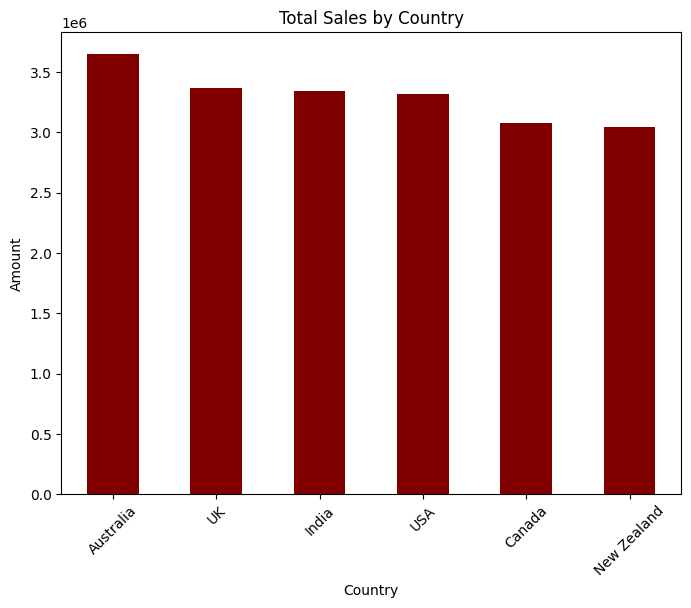

In [ ]:
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))

country_sales.plot(kind = 'bar',x ='Country', y= 'Amount',color = 'maroon')

plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Amount')
plt.xticks(rotation=45)

plt.show()

# Product-wise Sales Analysis

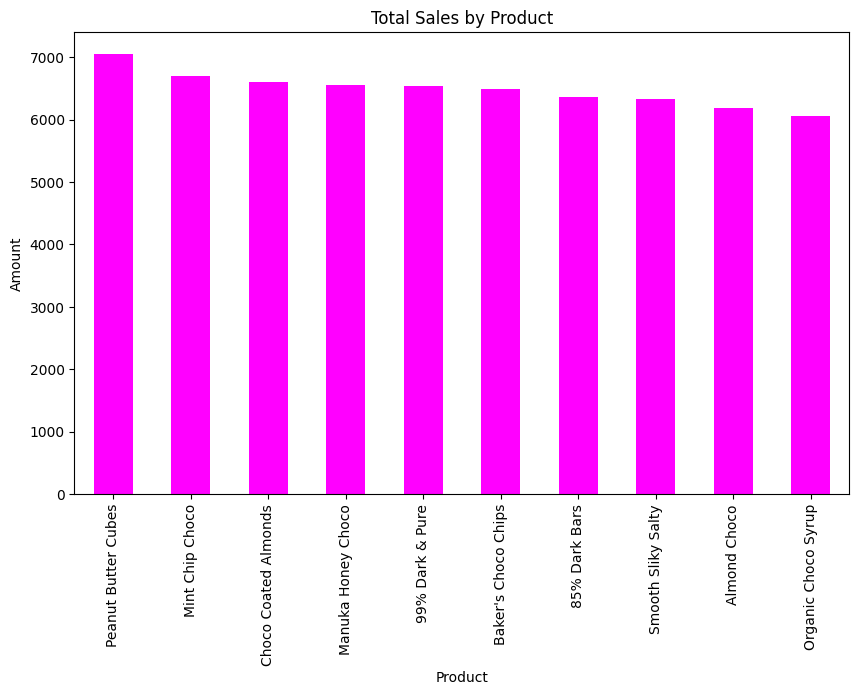

In [ ]:
product_sales = df.groupby('Product')['Amount'].mean().sort_values(ascending= False).head(10)
product_sales

plt.figure(figsize=(10,6))

product_sales.plot(kind ='bar',x ='Product',y ='Amount',color = 'magenta')

plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Amount')
plt.xticks(rotation=90)

plt.show()


# Monthly Revenue Trend

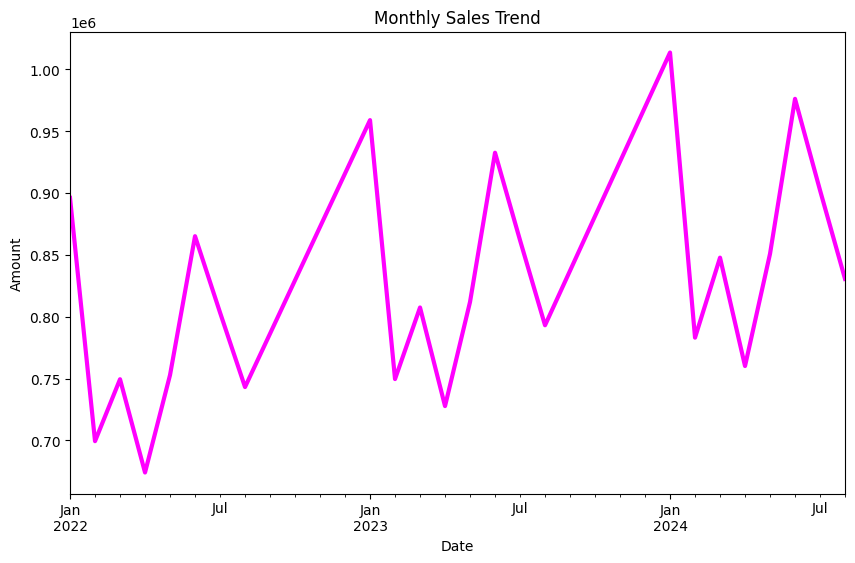

In [ ]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()

plt.figure(figsize=(10,6))

monthly_sales.plot(kind ='line',color = 'magenta',linewidth = '3')

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Amount')

plt.show()

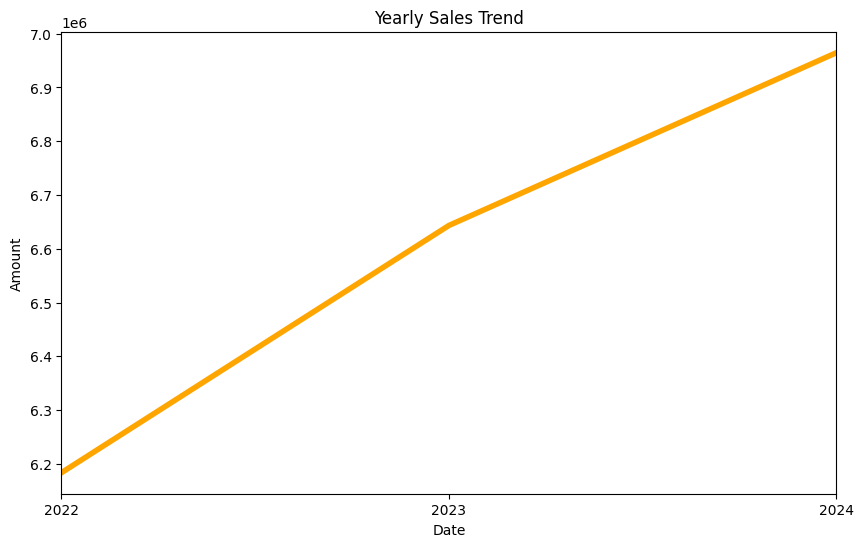

In [ ]:
yearly_sales = df.groupby(df['Date'].dt.to_period('Y'))['Amount'].sum()
yearly_sales

plt.figure(figsize=(10,6))

yearly_sales.plot(kind ='line',color = 'orange',linewidth ='4')

plt.title('Yearly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Amount')

plt.show()

# Countries with the most Sales Person

In [ ]:
x = df.groupby('Country')['Sales Person'].count().sort_values(ascending  = False)
x

,Sales Person
Country,
Australia,615
India,552
USA,537
UK,534
Canada,525
New Zealand,519


# TOP 10 SALES PERSON OVERALL

In [ ]:
Best_Sales_Person = df.groupby(['Sales Person','Country'])['Amount'].sum().sort_values(ascending= False).head(10)
Best_Sales_Person
pd.DataFrame(Best_Sales_Person)

,,Amount
Sales Person,Country,
Ches Bonnell,India,313021.88
Van Tuxwell,India,277532.36
Oby Sorrel,India,242478.98
Beverie Moffet,Canada,231510.29
Mallorie Waber,Australia,228112.72
Madelene Upcott,UK,227374.71
Jehu Rudeforth,UK,224407.74
Oby Sorrel,UK,223698.58
Kelci Walkden,USA,222169.21


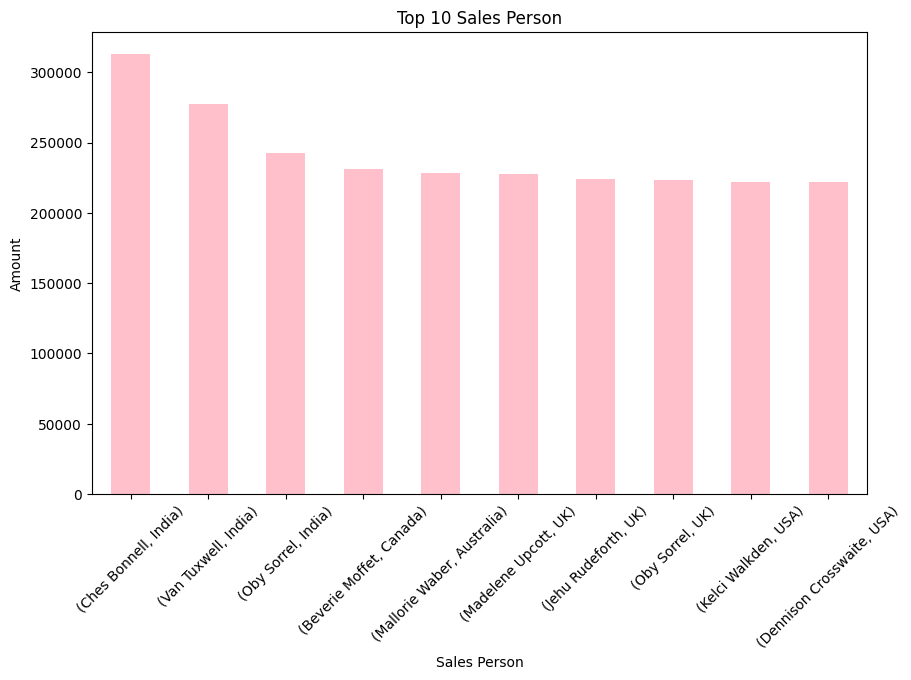

In [ ]:
plt.figure(figsize=(10,6))
Best_Sales_Person.plot(kind ='bar',x ='Sales Person',y ='Amount',color = 'pink')
plt.title('Top 10 Sales Person')
plt.xlabel('Sales Person')
plt.ylabel('Amount')
plt.xticks(rotation=45)

plt.show()

# BEST SALESPERSON IN ALL COUNTRIES

In [ ]:
# amountwise
sales_grouped = df.groupby(['Country', 'Sales Person'])['Amount'].sum().reset_index()
sales_grouped
pd.DataFrame(sales_grouped)

,Country,Sales Person,Amount
0,Australia,Andria Kimpton,98362.44
1,Australia,Barr Faughny,148599.65
2,Australia,Beverie Moffet,87891.54
3,Australia,Brien Boise,193359.38
4,Australia,Camilla Castle,101819.83
...,...,...,...
145,USA,Oby Sorrel,121570.09
146,USA,Rafaelita Blaksland,108023.98
147,USA,Roddy Speechley,127982.24
148,USA,Van Tuxwell,102654.66


In [ ]:
import plotly.express as px
px.treemap(sales_grouped, path=['Country', 'Sales Person'], values='Amount')

# TOP 5 BEST SALESPERSON ALL OVER

In [ ]:
best_per_country = sales_grouped.loc[sales_grouped.groupby('Country')['Amount'].idxmax()]
best_per_country = best_per_country.sort_values(by='Amount', ascending=False)
best_per_country

,Country,Sales Person,Amount
55,India,Ches Bonnell,313021.88
27,Canada,Beverie Moffet,231510.29
18,Australia,Mallorie Waber,228112.72
117,UK,Madelene Upcott,227374.71
141,USA,Kelci Walkden,222169.21
92,New Zealand,Madelene Upcott,215372.90


<Figure size 1000x600 with 0 Axes>

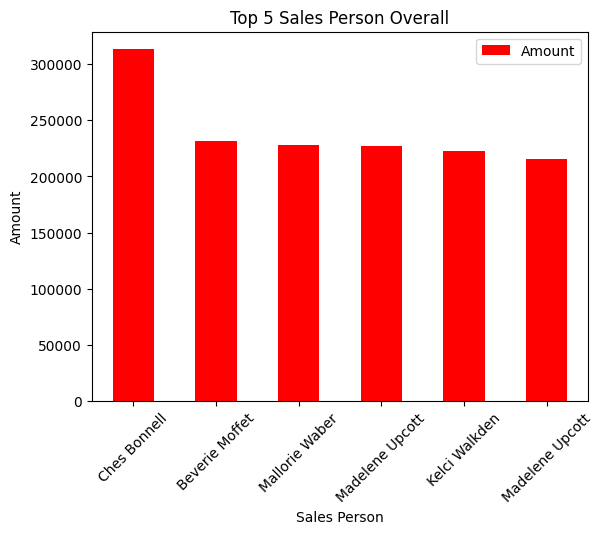

In [ ]:
plt.figure(figsize=(10,6))

best_per_country.plot(kind ='bar',x ='Sales Person',y ='Amount',color = 'red')

plt.title('Top 5 Sales Person Overall')
plt.xlabel('Sales Person')
plt.ylabel('Amount')
plt.xticks(rotation=45)

plt.show()

## Top 10 Products Amount-wise

In [ ]:
# Top 10 Products Amount-wise
Products = df.groupby('Product')['Amount'].sum().sort_values(ascending = False).head(10)
Products

,Amount
Product,
Smooth Sliky Salty,1120201.09
50% Dark Bites,1087659.35
White Choc,1054257.00
Peanut Butter Cubes,1036591.09
Eclairs,996947.96
99% Dark & Pure,960033.45
85% Dark Bars,955268.24
Organic Choco Syrup,945345.73
Spicy Special Slims,938131.69


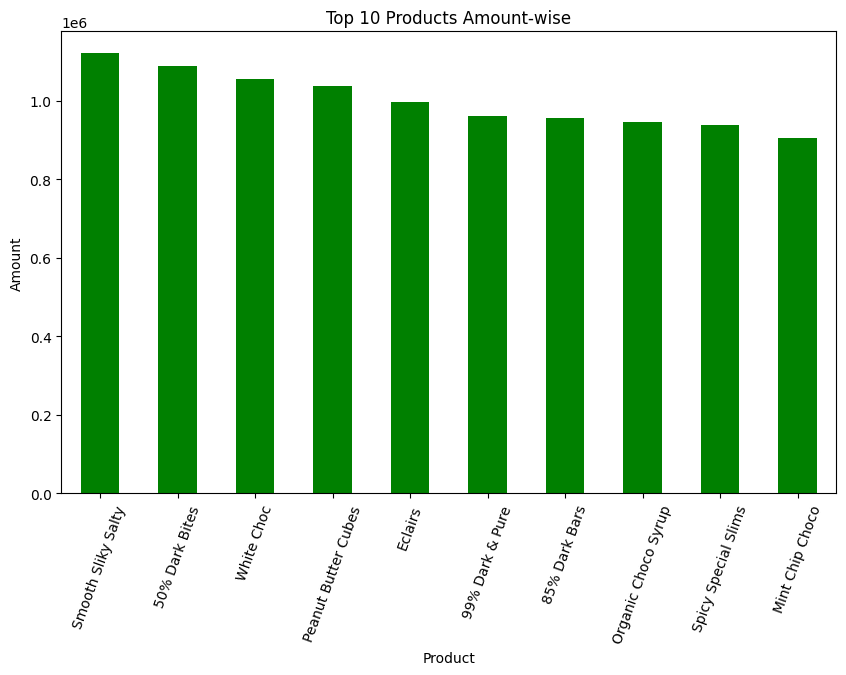

In [ ]:
plt.figure(figsize=(10,6))

Products.plot(kind ='bar', x = 'Product', y ='Amount',color = 'green')

plt.title('Top 10 Products Amount-wise')
plt.xlabel('Product')
plt.ylabel('Amount')
plt.xticks(rotation=70)

plt.show()

# Bottom 10 Products Amount-wise

In [ ]:
Products = df.groupby('Product')['Amount'].sum().sort_values(ascending = True).head(10)
Products

,Amount
Product,
70% Dark Bites,677346.22
Caramel Stuffed Bars,742516.15
Choco Coated Almonds,773062.91
Baker's Choco Chips,799085.67
Drinking Coco,822245.57
Orange Choco,824070.85
Fruit & Nut Bars,829278.96
After Nines,837215.67
Raspberry Choco,845388.41


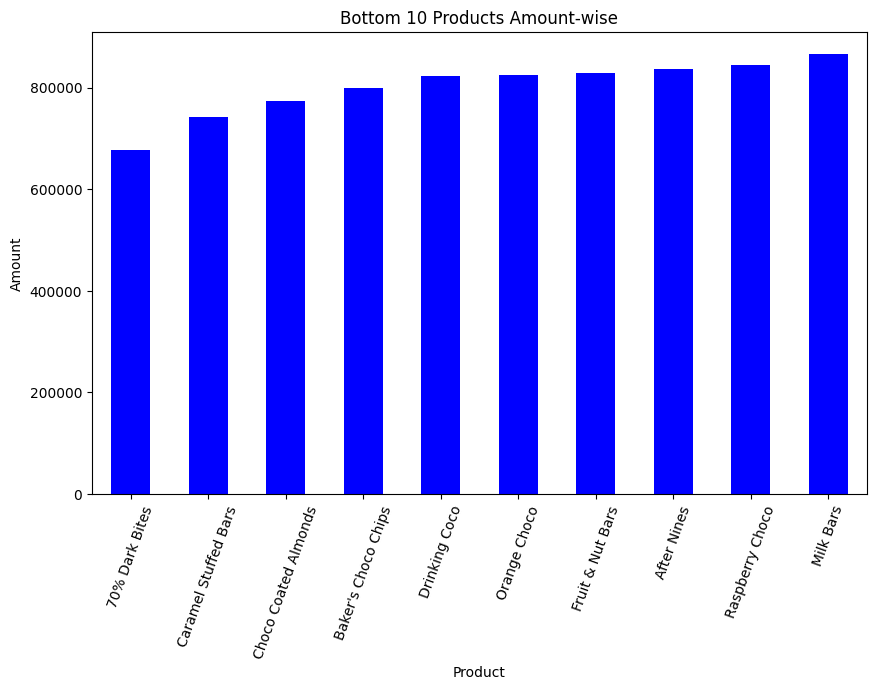

In [ ]:
plt.figure(figsize=(10,6))

Products.plot(kind ='bar', x = 'Product', y ='Amount',color = 'blue')

plt.title('Bottom 10 Products Amount-wise')
plt.xlabel('Product')
plt.ylabel('Amount')
plt.xticks(rotation=70)

plt.show()

In [ ]:
# Top 10 Products Boxes Shipped-wise
xproducts = df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending = False).head(10)
xproducts

,Boxes Shipped
Product,
50% Dark Bites,29810
Smooth Sliky Salty,26969
Eclairs,26678
Spicy Special Slims,26662
Caramel Stuffed Bars,26576
Drinking Coco,26402
Milk Bars,25436
Peanut Butter Cubes,25339
White Choc,25158


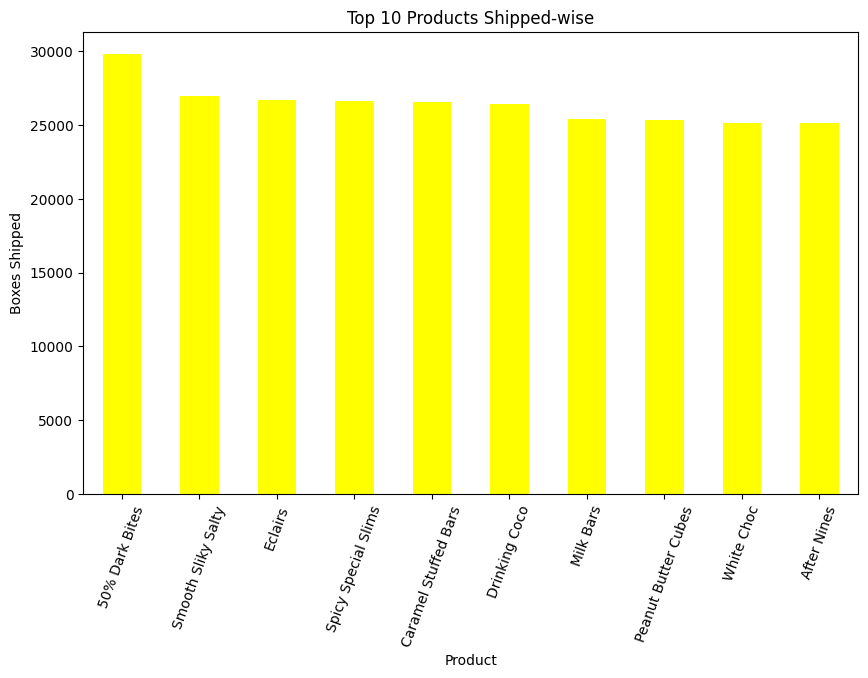

In [ ]:
plt.figure(figsize=(10,6))

xproducts.plot(kind ='bar', color = 'yellow')

plt.title('Top 10 Products Shipped-wise')
plt.xlabel('Product')
plt.ylabel('Boxes Shipped')
plt.xticks(rotation=70)

plt.show()

# Bottom 10 Products Boxes Shipped-wise

In [ ]:
# Bottom 10 Products Boxes Shipped-wise
xproducts = df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending = True).head(10)
xproducts

,Boxes Shipped
Product,
Choco Coated Almonds,19677
Almond Choco,20558
Baker's Choco Chips,21448
Raspberry Choco,21672
Organic Choco Syrup,23602
Orange Choco,23607
Fruit & Nut Bars,23632
Manuka Honey Choco,23736
85% Dark Bars,23828


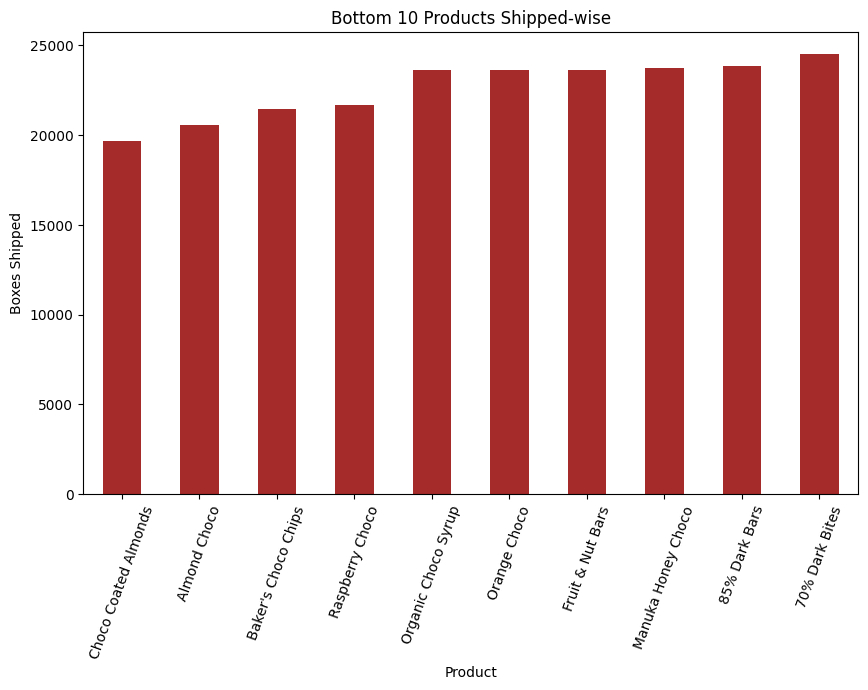

In [ ]:
plt.figure(figsize=(10,6))

xproducts.plot(kind ='bar', color = 'brown')

plt.title('Bottom 10 Products Shipped-wise')
plt.xlabel('Product')
plt.ylabel('Boxes Shipped')
plt.xticks(rotation=70)

plt.show()

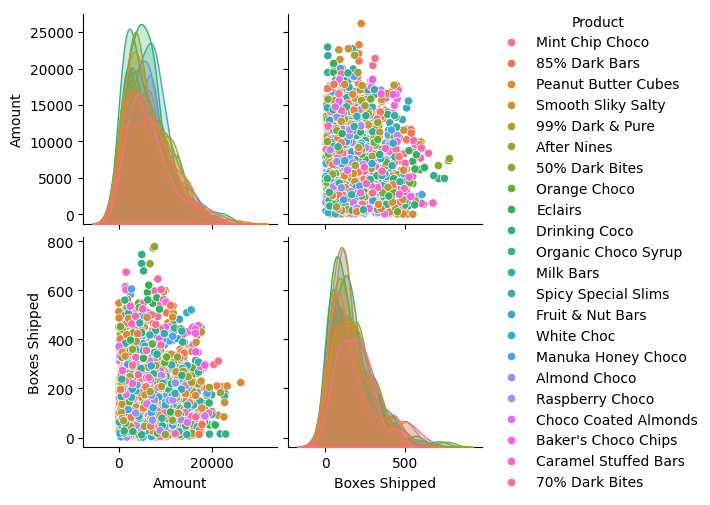

In [ ]:
sns.pairplot(df, hue='Product', palette='husl')
plt.show()

# FINAL CONCLUSION

Between 2022 – 2024


Australia generated the largest revenue: $3,646,444

Best-selling product: Smooth Silky Salty – $1,120,201

Worst-selling product: 70% Dark Bites – $677,346

January is the best month, generating the most revenue